**1. Importação das bibliotecas**

In [61]:
#Instalando Dependências
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [62]:
# Importação de bibliotecas e frameworks

# Pandas e Numpy
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import folium
from folium.plugins import HeatMap, MarkerCluster

# Utilitários
import textwrap
import json
import requests
import warnings

# Clustering e Pré-processamento
from kmodes.kmodes import KModes
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import DBSCAN

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from catboost import CatBoostClassifier

**2. Lendo o CSV**

In [63]:
file_path = 'datatran2024.csv'
df = pd.read_csv(file_path, sep=";", low_memory=False)
print("Dados carregados com sucesso. Primeiras 5 linhas:")
df.head()

Dados carregados com sucesso. Primeiras 5 linhas:


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,571789,01/01/2024,segunda-feira,03:56:00,ES,101,38,CONCEICAO DA BARRA,Ultrapassagem Indevida,Colisão lateral sentido oposto,...,1,1,1,1,3,-1.848.261,-3.992.379,SPRF-ES,DEL04-ES,UOP02-DEL04-ES
1,571804,01/01/2024,segunda-feira,04:50:00,PI,343,185,PIRIPIRI,Manobra de mudança de faixa,Colisão frontal,...,0,1,0,0,2,-429.603.281,-4.176.732.659,SPRF-PI,DEL02-PI,UOP01-DEL02-PI
2,571806,01/01/2024,segunda-feira,04:30:00,BA,116,578,BREJOES,Ingestão de álcool pelo condutor,Colisão frontal,...,0,1,2,0,4,-1.307.158.302,-399.611.107,SPRF-BA,DEL03-BA,UOP02-DEL03-BA
3,571818,01/01/2024,segunda-feira,06:30:00,SE,101,18,MALHADA DOS BOIS,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,...,1,0,2,1,3,-1.035.601.949,-3.690.552.235,SPRF-SE,DEL02-SE,UOP02-DEL02-SE
4,571838,01/01/2024,segunda-feira,05:00:00,MT,364,240,RONDONOPOLIS,Condutor deixou de manter distância do veículo...,Colisão traseira,...,0,2,1,0,3,-1.617.914.141,-5.478.905.337,SPRF-MT,DEL02-MT,UOP01-DEL02-MT


**3. Preparação de Dados**

In [64]:
# Criação da coluna 'hora'
# Converte o 'horario' (string) para um objeto datetime e extrai a hora
df['hora'] = pd.to_datetime(df['horario'], format='%H:%M:%S').dt.hour

# Criação da variável alvo 'acidente_grave'
# Define um acidente como grave (1) se a classificação for fatal/ferida, 
# ou se houver mortos ou feridos graves
df["acidente_grave"] = (
    (df["classificacao_acidente"].isin(["Com Vítimas Fatais", "Com Vítimas Feridas"])) |
    (df["mortos"].astype(float) > 0) |
    (df["feridos_graves"].astype(float) > 0)
).astype(int)

print("Colunas 'hora' e 'acidente_grave' criadas com sucesso. Amostra:")
df[['horario', 'hora', 'classificacao_acidente', 'mortos', 'feridos_graves', 'acidente_grave']].sample(5)

Colunas 'hora' e 'acidente_grave' criadas com sucesso. Amostra:


,horario,hora,classificacao_acidente,mortos,feridos_graves,acidente_grave
325,05:00:00,5,Com Vítimas Feridas,0,2,1
46475,06:55:00,6,Com Vítimas Feridas,0,0,1
7811,20:20:00,20,Com Vítimas Feridas,0,0,1
69590,22:00:00,22,Sem Vítimas,0,0,0
7186,12:36:00,12,Com Vítimas Fatais,1,0,1


**4. Exploração de Dados**

In [65]:
print("\nInformações sobre as colunas:")
df.info()

print("\nEstatísticas descritivas:")
df_describe = df.describe()


Informações sobre as colunas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73156 entries, 0 to 73155
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   id                      73156 non-null  object
 1   data_inversa            73156 non-null  object
 2   dia_semana              73156 non-null  object
 3   horario                 73156 non-null  object
 4   uf                      73156 non-null  object
 5   br                      73156 non-null  int64 
 6   km                      73156 non-null  object
 7   municipio               73156 non-null  object
 8   causa_acidente          73156 non-null  object
 9   tipo_acidente           73156 non-null  object
 10  classificacao_acidente  73155 non-null  object
 11  fase_dia                73156 non-null  object
 12  sentido_via             73156 non-null  object
 13  condicao_metereologica  73156 non-null  object
 14  tipo_pista             

**5. Perguntas de negócio**

- **Acidentes por estado**

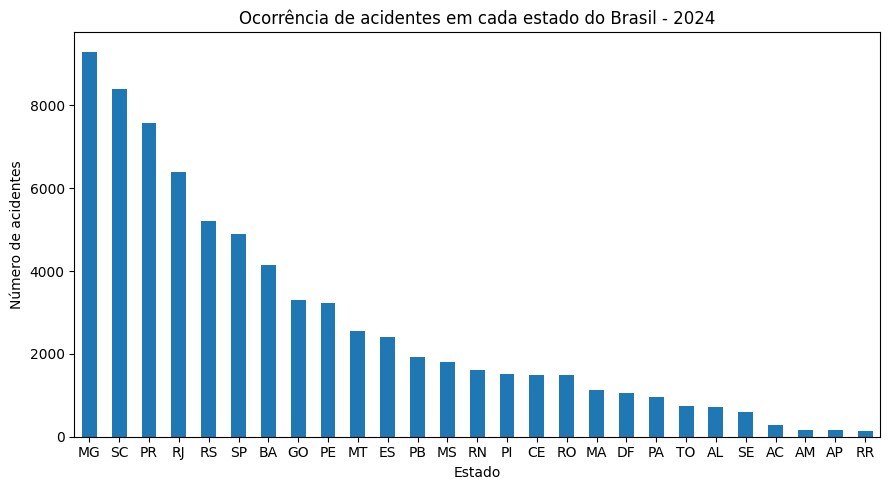

In [66]:
# Observando a contagem de acidentes por estado em 2024
df['uf'].value_counts().head()
top_estados = df['uf'].value_counts()
plt.figure(figsize=(9, 5))
top_estados.plot(kind='bar')
plt.title('Ocorrência de acidentes em cada estado do Brasil - 2024')
plt.xlabel('Estado')
plt.ylabel('Número de acidentes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

- **Horário e dia da semana que mais ocorrem acidentes**

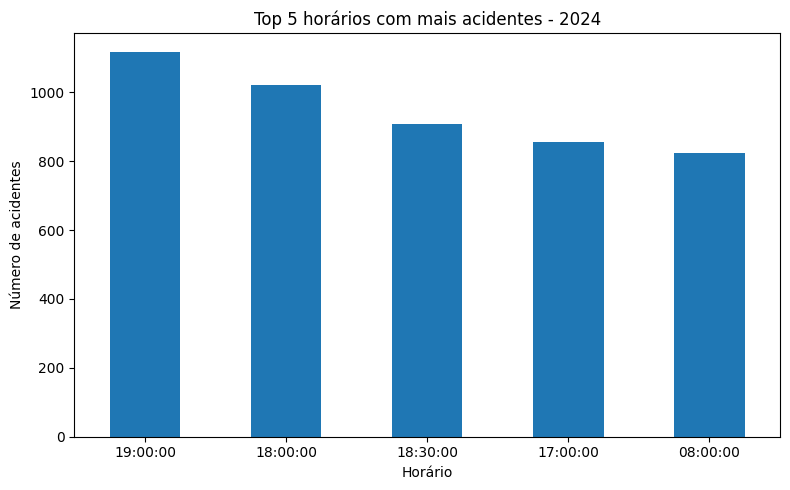

Faixa de horário com mais acidentes: das 17h às 19h


In [67]:
# Observando em qual dia e horário mais ocorrem
df['horario'].value_counts().head()
top_horarios = df['horario'].value_counts().head(5)
plt.figure(figsize=(8, 5))
top_horarios.plot(kind='bar')
plt.title('Top 5 horários com mais acidentes - 2024')
plt.xlabel('Horário')
plt.ylabel('Número de acidentes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
## Adicionar gráfico e horário médio de acidentes (em média, em qual horário ocorrem mais acidentes)
faixa = df['hora'].value_counts().head(3).index.sort_values()
print(f'Faixa de horário com mais acidentes: das {faixa[0]:02d}h às {faixa[-1]:02d}h')

dia_semana
domingo          11741
sábado           11641
sexta-feira      11300
segunda-feira    10208
quinta-feira      9570
quarta-feira      9384
terça-feira       9312
Name: count, dtype: int64


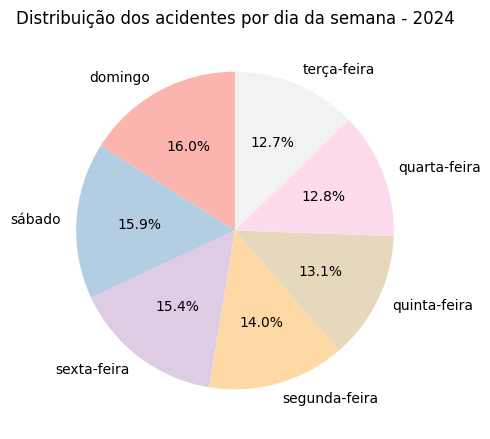

In [68]:
df['dia_semana'].value_counts()
dias = df['dia_semana'].value_counts()
print(dias)
plt.figure(figsize=(5, 5))
plt.pie(dias.values, labels=dias.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Pastel1(np.linspace(0, 1, len(dias))))
plt.title('Distribuição dos acidentes por dia da semana - 2024')
plt.tight_layout()
plt.show()

- **Brs com maior ocorrecias de acidentes dentro do estado de Minas Gerais**


BR com mais acidentes em MG: BR-381 (2793 ocorrências).


br
381    2793
40     1791
116    1383
262    1058
365     634
50      599
251     276
153     263
267     156
459     101
Name: count, dtype: int64

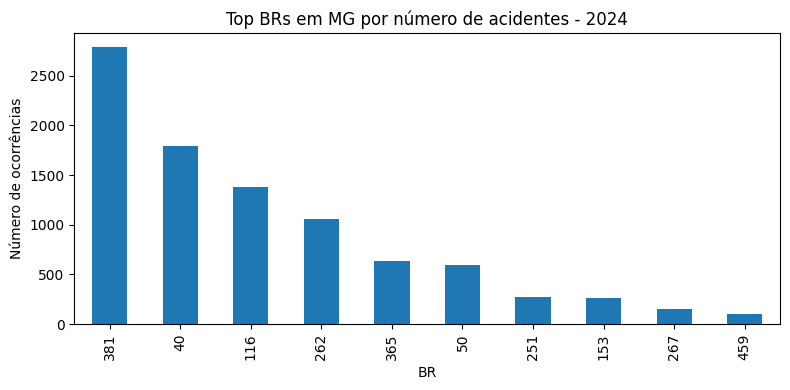

In [69]:
# BRs mais críticas dentro do estado com mais acidentes
acidentes_por_uf = df["uf"].value_counts()
estado_top = acidentes_por_uf.idxmax()
br_no_estado_top = df.loc[df["uf"] == estado_top, "br"].value_counts()

print(f"\nBR com mais acidentes em {estado_top}: BR-{br_no_estado_top.idxmax()} ({br_no_estado_top.max()} ocorrências).")
display(br_no_estado_top.head(10))

br_no_estado_top.head(10).plot(kind="bar", figsize=(8, 4))
plt.title(f"Top BRs em {estado_top} por número de acidentes - 2024")
plt.xlabel("BR")
plt.ylabel("Número de ocorrências")
plt.tight_layout()
plt.show()

- **Maior causa de acidentes**

Top 10 causas de acidentes:

A principal causa dos acidentes é: Reação tardia ou ineficiente do condutor (10920 ocorrências).


causa_acidente
Reação tardia ou ineficiente do condutor                     10920
Ausência de reação do condutor                               10664
Acessar a via sem observar a presença dos outros veículos     6958
Condutor deixou de manter distância do veículo da frente      4460
Velocidade Incompatível                                       4347
Manobra de mudança de faixa                                   4213
Ingestão de álcool pelo condutor                              3854
Demais falhas mecânicas ou elétricas                          3390
Transitar na contramão                                        2461
Condutor Dormindo                                             2136
Name: count, dtype: int64

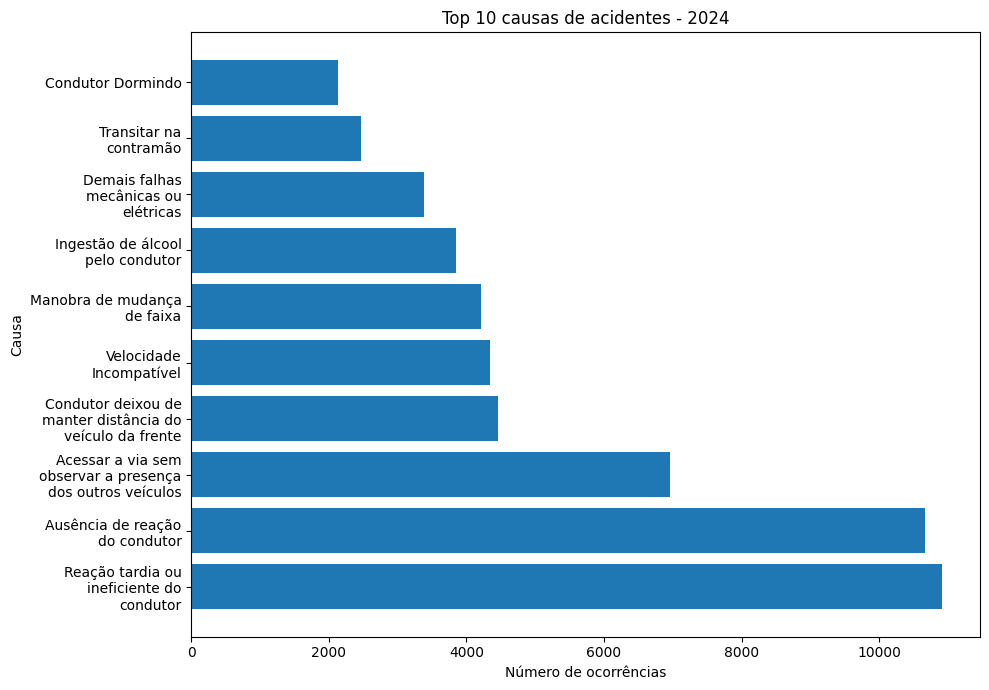

In [70]:
# Qual é a maior causa dos acidentes?
causas = df["causa_acidente"].value_counts()

print("Top 10 causas de acidentes:")
print(f"\nA principal causa dos acidentes é: {causas.idxmax()} ({causas.max()} ocorrências).")
display(causas.head(10))

labels = [textwrap.fill(label, width=20) for label in causas.head(10).index]

plt.figure(figsize=(10, 7))
plt.barh(labels, causas.head(10).values)
plt.title("Top 10 causas de acidentes - 2024")
plt.xlabel("Número de ocorrências")
plt.ylabel("Causa")
plt.tight_layout()
plt.show()

- **Acidentes por condição meteorológica**

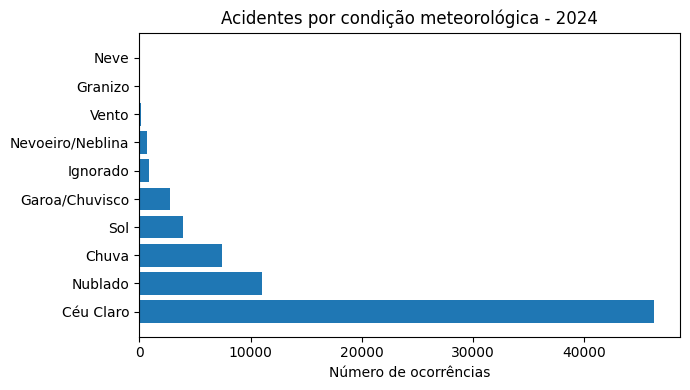

In [71]:
# O clima influencia nos acidentes?
clima = df['condicao_metereologica'].value_counts()
plt.figure(figsize=(7, 4))
plt.barh(clima.index, clima.values)
plt.title("Acidentes por condição meteorológica - 2024")
plt.xlabel("Número de ocorrências")
plt.tight_layout()
plt.show()

- **Acidentes por hora x condição meteorológica**

Tabela de acidentes por hora x condição meteorológica:


condicao_metereologica,Chuva,Céu Claro,Garoa/Chuvisco,Granizo,Ignorado,Neve,Nevoeiro/Neblina,Nublado,Sol,Vento
hora,,,,,,,,,,
0,145,878,108,0,35,0,26,264,1,1
1,154,816,69,0,37,0,31,261,0,5
2,100,748,75,0,39,0,30,211,0,8
3,114,800,72,0,48,0,48,249,0,7
4,128,953,84,0,59,0,47,259,4,2
5,197,1427,100,0,57,0,93,336,26,4
6,305,2028,123,0,36,0,88,470,148,3
7,354,2960,152,0,23,0,57,653,395,2
8,309,2381,142,0,11,0,28,510,345,1


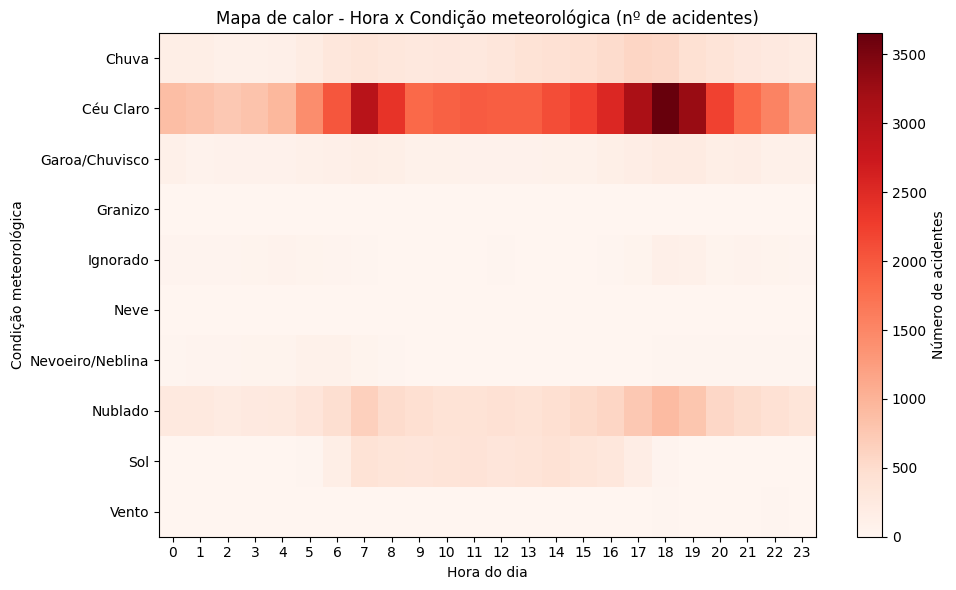


Tabela de acidentes por hora x principais causas:


causa_acidente,Acessar a via sem observar a presença dos outros veículos,Ausência de reação do condutor,Condutor deixou de manter distância do veículo da frente,Reação tardia ou ineficiente do condutor,Velocidade Incompatível
hora,,,,,
0,44,255,39,241,103
1,32,278,25,222,103
2,31,228,20,177,96
3,30,250,19,205,94
4,65,289,38,199,95
5,99,401,70,321,140
6,244,521,193,517,228
7,499,653,447,654,259
8,379,535,307,604,243


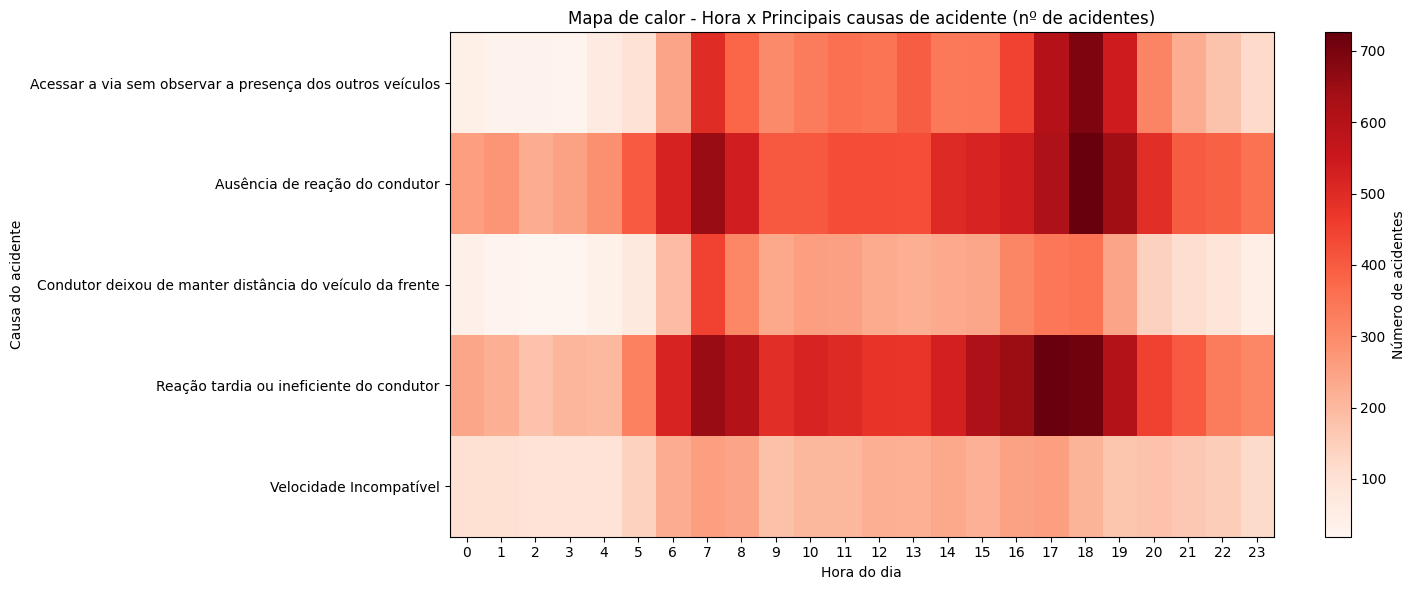

In [72]:
# Existe relação entre horário e clima com as causas de acidentes?

# Garante que a coluna "hora" existe
if "hora" not in df.columns:
    df["hora"] = pd.to_datetime(df["horario"], format="%H:%M:%S").dt.hour

# Tabela hora x condição climática
tabela_hora_clima = pd.pivot_table(
    df,
    index="hora",
    columns="condicao_metereologica",
    values="id",
    aggfunc="count"
).fillna(0).astype(int)

print("Tabela de acidentes por hora x condição meteorológica:")
display(tabela_hora_clima)

plt.figure(figsize=(10, 6))
plt.imshow(tabela_hora_clima.T, aspect="auto", cmap="Reds")
plt.colorbar(label="Número de acidentes")
plt.yticks(range(len(tabela_hora_clima.columns)), tabela_hora_clima.columns)
plt.xticks(range(0, 24), range(0, 24))
plt.xlabel("Hora do dia")
plt.ylabel("Condição meteorológica")
plt.title("Mapa de calor - Hora x Condição meteorológica (nº de acidentes)")
plt.tight_layout()
plt.show()

# Relação horário x principais causas de acidente
principais_causas = df["causa_acidente"].value_counts().head(5).index
df_causas_top = df[df["causa_acidente"].isin(principais_causas)]

tabela_hora_causa = pd.pivot_table(
    df_causas_top,
    index="hora",
    columns="causa_acidente",
    values="id",
    aggfunc="count"
).fillna(0)

print("\nTabela de acidentes por hora x principais causas:")
display(tabela_hora_causa)

plt.figure(figsize=(15, 6))
plt.imshow(tabela_hora_causa.T, aspect="auto", cmap="Reds")
plt.colorbar(label="Número de acidentes")
plt.yticks(range(len(tabela_hora_causa.columns)), tabela_hora_causa.columns)
plt.xticks(range(0, 24), range(0, 24))
plt.xlabel("Hora do dia")
plt.ylabel("Causa do acidente")
plt.title("Mapa de calor - Hora x Principais causas de acidente (nº de acidentes)")
plt.tight_layout()
plt.show()

## Por que a maioria dos acidentes ocorrem domingo no período das 17h às 19h?
Essa questão está relacionada principalmente em relação aos fatores:
- Falta de fiscalização
- Visibilidade menor
- Falta de atenção.
- Fadiga
Analisando o conjunto de dados, vemos que a maioria ocorrem domingo e sábado, isto é, são finais de semana. Isto pode estar relacionado com o fato de que as pessoas se importam menos com a segurança no trânsito nesses dias (https://www.portaldotransito.com.br/noticias/fiscalizacao-e-legislacao/estatisticas/estudo-mostra-que-mortes-no-transito-acontecem-mais-aos-finais-de-semana/). Além disso, dias de finais de semana possuem menos fiscalização, e são dias que a fadiga dos condutores fica maior.

## Por que os acidentes ocorrem mais em Minas Gerais do que em outros estados? E por que a colisão traseira é a mais comum?
Em relação a ser em Minas Gerais, vários fatores podem contribuir. O estado possui uma das rodovias mais perigosas do país, a BR-381, e isso pode estar relacionado com trechos perigosos e falta de sinalização. Já em relação a colisão traseira, a causa mais provável é a falta de atenção em relação aos condutores. Por conta de muitas vezes termos fluxo intenso de veículos e trechos perigosos, é preciso frear para evitar esse tipo de acidente, além de manter distância do veículo que está na frente.

## Mapa de calor

In [73]:
# 1. CARREGAR DADOS
ranking = df["uf"].value_counts().reset_index()
ranking.columns = ["uf", "acidentes"]
print("Ranking de Acidentes por UF:")
print(ranking.head())

total_acidentes = ranking["acidentes"].sum()
ranking["percentual"] = (ranking["acidentes"] / total_acidentes * 100).round(2)

# 2. CARREGAR GEOJSON DOS ESTADOS
geojson_url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
geojson_data = requests.get(geojson_url).json()

# 3. CALCULAR CENTROS (CENTROIDES) DOS ESTADOS
def calcular_centroid(coordinates):
    """ Calcula centroide médio da geometria do estado """
    longs = []
    lats = []

    def extract(coords):
        for c in coords:
            if isinstance(c[0], list):
                extract(c)
            else:
                longs.append(c[0])
                lats.append(c[1])

    extract(coordinates)
    return (sum(lats) / len(lats), sum(longs) / len(longs))

centroids = {}
for feature in geojson_data["features"]:
    uf = feature["properties"]["sigla"]
    coords = feature["geometry"]["coordinates"]
    centroids[uf] = calcular_centroid(coords)

# 4. MAPA BASE
mapa = folium.Map(
    location=[-14.235, -51.925],
    zoom_start=4,
    tiles="cartodbpositron"
)

# 5. CHOROPLETH (HEATMAP POR ESTADO)
folium.Choropleth(
    geo_data=geojson_data,
    name="choropleth",
    data=ranking,
    columns=["uf", "acidentes"],
    key_on="feature.properties.sigla",
    fill_color="YlOrRd",
    fill_opacity=0.8,
    line_opacity=0.4,
    nan_fill_color="white",
    legend_name="Total de Acidentes por Estado (PRF 2024)"
).add_to(mapa)

# 6. ADICIONAR LABELS (UF + %)
for _, row in ranking.iterrows():
    uf = row["uf"]
    acidentes = row["acidentes"]
    pct = row["percentual"]
    lat, lon = centroids[uf]

    folium.map.Marker(
        [lat, lon],
        icon=folium.DivIcon(
            html=f"""
            <div style="font-size:12px; font-weight:bold; color:#000; text-align:center;">
                {uf}<br>{pct}% 
            </div>
            """
        )
    ).add_to(mapa)

# 7. SALVAR MAPA
mapa.save("heatmap_estados_brasil.html")
print("Mapa salvo como heatmap_estados_brasil.html")



Ranking de Acidentes por UF:
   uf  acidentes
0  MG       9296
1  SC       8381
2  PR       7576
3  RJ       6389
4  RS       5206
Mapa salvo como heatmap_estados_brasil.html


## Importância das Features com CatBoost


=== RESULTADOS - CatBoost ===
              precision    recall  f1-score   support

           0       0.77      0.22      0.34      2945
           1       0.87      0.99      0.92     15344

    accuracy                           0.86     18289
   macro avg       0.82      0.60      0.63     18289
weighted avg       0.85      0.86      0.83     18289


=== Importância das Features - CatBoost ===
                Feature Id  Importances
0            tipo_acidente    34.541911
1           causa_acidente    15.440880
2                       uf     8.782161
3               tipo_pista     5.732383
4                 fase_dia     4.973025
5                     hora     4.946217
6              sentido_via     4.595635
7               dia_semana     4.075306
8                       km     3.499078
9                  horario     3.395994
10             tracado_via     3.065608
11                      br     2.988296
12  condicao_metereologica     2.477034
13                uso_solo     1.4864

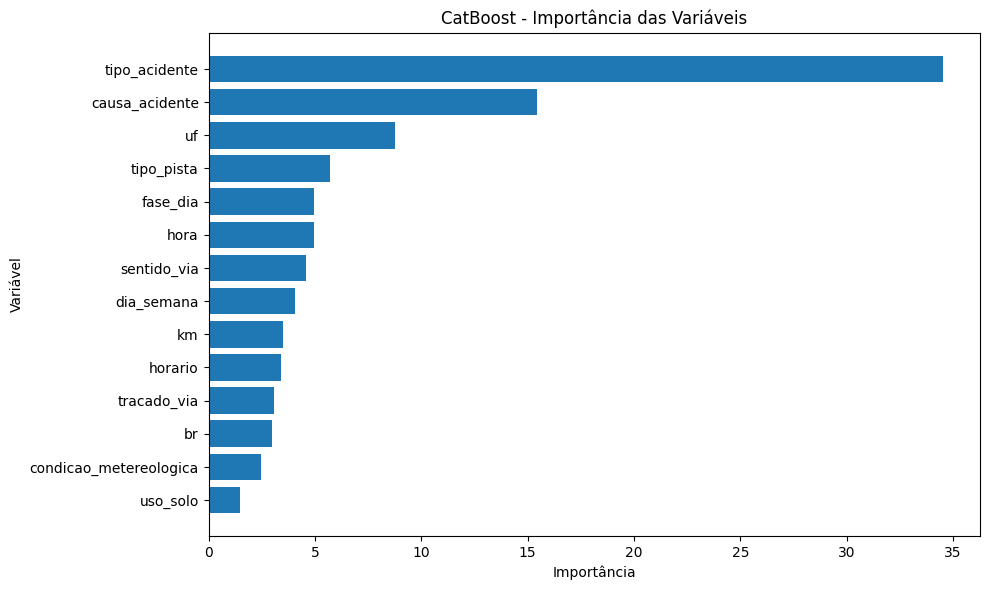

In [74]:
warnings.filterwarnings("ignore")

# REMOVER COLUNAS QUE NÃO PODEM SER FEATURES
drop_cols = [
    "id",
    "data_inversa",
    "municipio",
    "classificacao_acidente",
    "pessoas",
    "mortos",
    "feridos_leves",
    "feridos_graves",
    "feridos",
    "ilesos",
    "ignorados",
    "veiculos",
    "latitude",
    "longitude",
    "regional",
    "delegacia",
    "uop",
    "acidente_grave"
]

X = df.drop(columns=drop_cols)
y = df["acidente_grave"]

# TRATAR CATEGÓRICAS
X_cat = X.copy()
categorical_cols = [col for col in X_cat.columns if X_cat[col].dtype == "object"]

for col in categorical_cols:
    X_cat[col] = X_cat[col].astype(str)

# TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X_cat, y, test_size=0.25, random_state=42, stratify=y
)

# TREINAR CATBOOST
cat = CatBoostClassifier(
    depth=6,
    iterations=400,
    learning_rate=0.05,
    verbose=False
)

cat.fit(X_train, y_train, cat_features=categorical_cols)

preds = cat.predict(X_test)

print("\n=== RESULTADOS - CatBoost ===")
print(classification_report(y_test, preds))

# IMPORTÂNCIA DAS FEATURES (CatBoost)
df_imp = cat.get_feature_importance(prettified=True)
df_imp["Importances"] = df_imp["Importances"].astype(float)
df_imp = df_imp.sort_values("Importances", ascending=False)

print("\n=== Importância das Features - CatBoost ===")
print(df_imp)

# GRÁFICO SIMPLES DE IMPORTÂNCIA
plt.figure(figsize=(10, 6))
plt.barh(df_imp["Feature Id"], df_imp["Importances"])
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.title("CatBoost - Importância das Variáveis")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Clusterização K-Modes e Identificação de Hotspots Geográficos

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 20541, cost: 561149.0
Run 1, iteration: 2/100, moves: 10164, cost: 561149.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 20485, cost: 561939.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 20977, cost: 555053.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 21241, cost: 566534.0
Run 4, iteration: 2/100, moves: 317, cost: 566534.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 5, iteration: 1/100, moves: 16941, cost: 564870.0
Best run was number 3


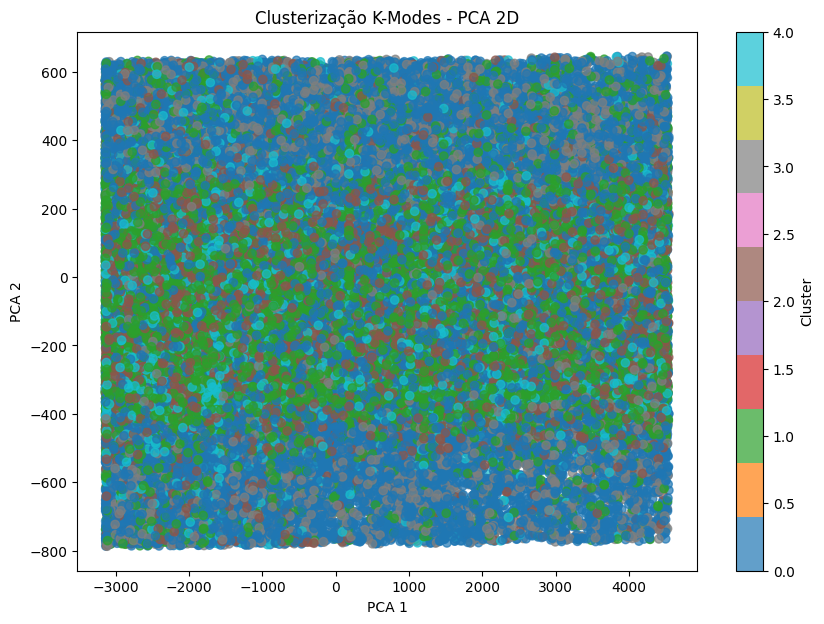


=== PERFIL DOS CLUSTERS (K-Modes) ===
                  dia_semana   horario  uf   br km  \
cluster_kmodes                                       
0                    domingo  19:00:00  MG  116  0   
1                sexta-feira  07:30:00  SC  101  0   
2                    domingo  15:30:00  RJ  116  1   
3                     sábado  19:00:00  MG  101  7   
4               quinta-feira  08:00:00  SP  116  2   

                                                   causa_acidente  \
cluster_kmodes                                                      
0                                  Ausência de reação do condutor   
1               Acessar a via sem observar a presença dos outr...   
2               Condutor deixou de manter distância do veículo...   
3                        Reação tardia ou ineficiente do condutor   
4                        Reação tardia ou ineficiente do condutor   

                                tipo_acidente     fase_dia  sentido_via  \
cluster_kmodes         

In [75]:
# Lista de colunas usadas na clusterização categórica
cols = [
    "dia_semana",
    "horario",
    "uf",
    "br",
    "km",
    "causa_acidente",
    "tipo_acidente",
    "fase_dia",
    "sentido_via",
    "condicao_metereologica",
    "tipo_pista",
    "tracado_via",
    "uso_solo"
]

# Extrair dados garantindo tipo string e preenchendo vazios
data = df[cols].astype(str).fillna("NA")

# Aplicar K-Modes (clusterização para variáveis categóricas)
km = KModes(n_clusters=5, init="Huang", n_init=5, verbose=1)
clusters = km.fit_predict(data)

# Salvar cluster categórico no dataframe
df["cluster_kmodes"] = clusters

# Encoder numérico temporário para redução de dimensionalidade
data_encoded = data.copy()
for col in data_encoded.columns:
    data_encoded[col] = LabelEncoder().fit_transform(data_encoded[col])

# Aplicar PCA para visualização 2D dos clusters
pca = PCA(n_components=2)
points_2d = pca.fit_transform(data_encoded)

# Salvar componentes PCA no dataframe
df["pca1"] = points_2d[:, 0]
df["pca2"] = points_2d[:, 1]

# Plot de clusters categóricos em 2D
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    df["pca1"], df["pca2"],
    c=df["cluster_kmodes"],
    cmap="tab10",
    alpha=0.7
)
plt.title("Clusterização K-Modes - PCA 2D")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(scatter, label="Cluster")
plt.show()

# Função segura para converter coordenadas se vierem como string mal formatada
def fix_coord(x):
    x = str(x).replace(".", "").replace(",", ".")
    try:
        return float(x)
    except:
        return None

# Criar versões tratadas de latitude/longitude
df["lat"] = df["latitude"].apply(fix_coord) / 1e7
df["lon"] = df["longitude"].apply(fix_coord) / 1e7

coords = df[["lat", "lon"]].dropna()

# Aplicar DBSCAN para clusters espaciais (proximidade geográfica)
db = DBSCAN(eps=0.03, min_samples=25).fit(coords)
df.loc[coords.index, "geo_cluster"] = db.labels_

# Criar mapa base com Folium
mapa = folium.Map(location=[-14.235, -51.925], zoom_start=4)
marker_cluster = MarkerCluster().add_to(mapa)

# Adicionar pontos no mapa com cor baseada no cluster geográfico
for _, row in df.dropna(subset=["lat", "lon"]).iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=3,
        color=f"#{int((row['geo_cluster']*9876543) if pd.notna(row['geo_cluster']) else 0) % 0xFFFFFF:06x}",
        fill=True,
        fill_opacity=0.7
    ).add_to(marker_cluster)

# Mostrar Mapa
mapa

# Criar relatório do cluster categórico: valores mais frequentes por grupo
relatorio = df.groupby("cluster_kmodes")[cols].agg(lambda x: x.value_counts().index[0])

# Exibir perfil dos clusters categóricos
print("\n=== PERFIL DOS CLUSTERS (K-Modes) ===")
print(relatorio)

# Exibir quantidade de acidentes por cluster categórico
print("\n=== QUANTIDADE DE ACIDENTES POR CLUSTER ===")
print(df["cluster_kmodes"].value_counts())


## Conclusão 
Com base nos dados, os fatores que mais influenciam os acidentes nas rodovias brasileiras são, principalmente, relacionados ao comportamento dos condutores (desatenção, velocidade incompatível, falta de distância segura e manobras inadequadas), potencializados por horários críticos (fim de tarde/noite), finais de semana e, em menor grau, por condições climáticas adversas.